# Problema Diario, CMO Termico e Permutacoes Sazonais

Este notebook constroi um estudo diario simples e direto, mas ancorado nos dados do SIN 2025. A ideia e observar a termica como variavel central de decisao e interpretar o CMO a partir do custo marginal da geracao termica.

Modelos usados:

- **Visao do operador/planner:** minimizar `sum(gt_t^2)` sujeito ao balanco `gt_t + gh_t + gs1_t + gs2_t = D_t`.
- **Visao do agente termico:** maximizar `pi_t gt_t - gt_t^2`, o que gera a oferta otima `gt_t = pi_t / 2`.
- **Ligacao com o CMO:** quando a termica e marginal, temos `CMO_t ~= pi_t = 2 gt_t`.

O sistema estudado tera:

- dois paineis solares com capacidades distintas;
- uma usina hidreletrica agregada com orcamento diario de agua;
- uma usina termica agregada;
- um bloco simples de transmissao para o segundo painel solar.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cvxpy as cp

from validate_model.pipeline import SINPaths, build_panel, load_hidrologia

pd.set_option("display.max_columns", 200)
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 10,
})

paths = SINPaths(root="validate_model", year=2025)


## 1. Base SIN 2025 e selecao de dias representativos

In [2]:
panel = build_panel(paths)

sin = (
    panel
    .groupby("din_instante", as_index=False)
    .agg({
        "D": "sum",
        "gs": "sum",
        "gr": "sum",
        "gh": "sum",
        "gn_obs": "sum",
    })
    .sort_values("din_instante")
    .reset_index(drop=True)
)

hydro_daily = load_hidrologia(paths.hidro_di_path)
hydro_daily["date"] = pd.to_datetime(hydro_daily["din_instante"]).dt.normalize()
sin["date"] = sin["din_instante"].dt.normalize()
sin = sin.merge(hydro_daily[["date", "A_MW"]], on="date", how="left")
sin["A_MW"] = sin["A_MW"].interpolate(method="linear").bfill().ffill()

season_map = {
    12: "Verao", 1: "Verao", 2: "Verao",
    3: "Outono", 4: "Outono", 5: "Outono",
    6: "Inverno", 7: "Inverno", 8: "Inverno",
    9: "Primavera", 10: "Primavera", 11: "Primavera",
}
sin["season"] = sin["din_instante"].dt.month.map(season_map)
sin["day_type"] = np.where(sin["din_instante"].dt.weekday < 5, "Dia util", "Fim de semana")

daily_meta = (
    sin.groupby("date")
    .agg(
        demand_GWh=("D", "sum"),
        solar_GWh=("gs", "sum"),
        hydro_GWh=("gh", "sum"),
        season=("season", "first"),
        day_type=("day_type", "first"),
        n_hours=("D", "size"),
    )
    .reset_index()
)
daily_meta = daily_meta[daily_meta["n_hours"] == 24].copy()


def representative_day(meta: pd.DataFrame, season: str, day_type: str) -> pd.Timestamp:
    group = meta[(meta["season"] == season) & (meta["day_type"] == day_type)].copy()
    if group.empty:
        raise ValueError(f"Sem dados para {season} | {day_type}")
    med = group["demand_GWh"].median()
    idx = (group["demand_GWh"] - med).abs().idxmin()
    return pd.Timestamp(group.loc[idx, "date"])


rep_rows = []
for season in ["Verao", "Outono", "Inverno", "Primavera"]:
    for day_type in ["Dia util", "Fim de semana"]:
        day = representative_day(daily_meta, season, day_type)
        row = daily_meta.loc[daily_meta["date"] == day].iloc[0]
        rep_rows.append({
            "label": f"{season} | {day_type}",
            "date": day,
            "demand_GWh": row["demand_GWh"] / 1e3,
            "solar_GWh": row["solar_GWh"] / 1e3,
            "hydro_GWh": row["hydro_GWh"] / 1e3,
        })

rep_days = pd.DataFrame(rep_rows)
display(rep_days.round(3))


Carregando demanda efetiva...
  [CHECK] 28,512 linhas
Carregando geração por fonte...
  [CHECK] solar: 29,664 linhas
  [CHECK] wind: 29,664 linhas
  [CHECK] nuclear: 7,416 linhas
  [CHECK] thermal: 29,664 linhas
  [CHECK] hydro: 29,664 linhas
  Total de gerações: 126,072 linhas
Carregando intercâmbio interno...
  [CHECK] 33,600 linhas

Painel montado: 29,664 linhas
Subsistemas: ['N', 'NE', 'S', 'SE']
Período: 2025-01-01 00:00:00 → 2025-11-05 23:00:00


,label,date,demand_GWh,solar_GWh,hydro_GWh
0,Verao | Dia util,2025-02-06,2171.419,243.783,1562.773
1,Verao | Fim de semana,2025-01-11,1876.999,256.871,1314.736
2,Outono | Dia util,2025-05-08,1971.577,234.677,1211.740
3,Outono | Fim de semana,2025-03-23,1805.497,255.425,1175.401
4,Inverno | Dia util,2025-06-02,1846.894,200.922,1016.733
5,Inverno | Fim de semana,2025-08-24,1643.556,217.137,760.810
6,Primavera | Dia util,2025-09-15,1921.809,267.524,935.998
7,Primavera | Fim de semana,2025-09-27,1677.723,244.366,771.813


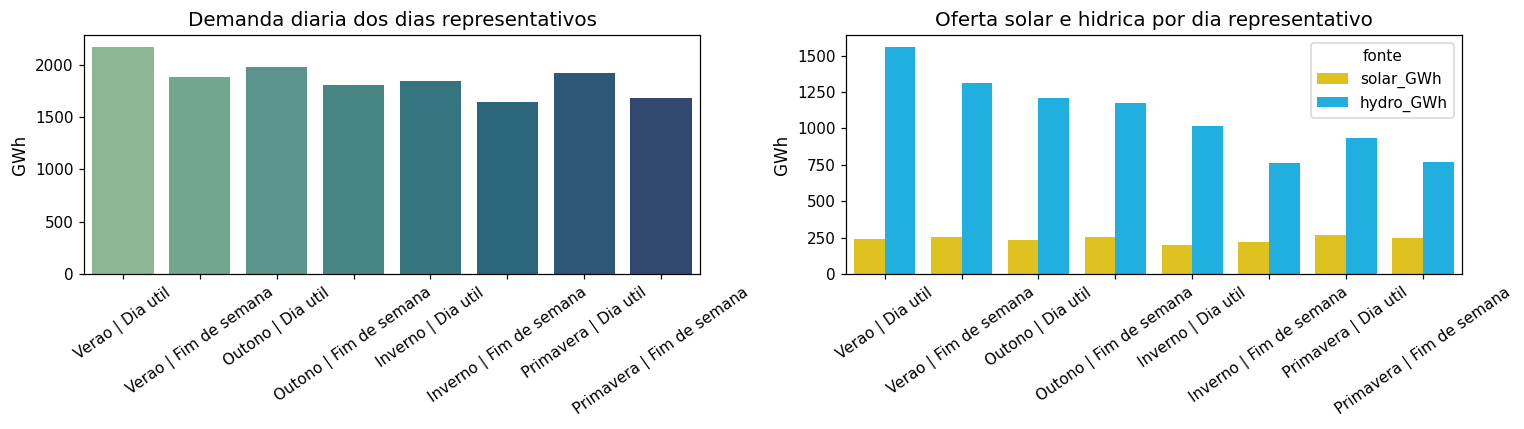

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
sns.barplot(data=rep_days, x="label", y="demand_GWh", hue="label", dodge=False, ax=ax, palette="crest")
ax.set_title("Demanda diaria dos dias representativos")
ax.set_ylabel("GWh")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=35)
if ax.legend_ is not None:
    ax.legend_.remove()

ax = axes[1]
tmp = rep_days.melt(
    id_vars=["label"],
    value_vars=["solar_GWh", "hydro_GWh"],
    var_name="fonte",
    value_name="energia_GWh",
)
sns.barplot(data=tmp, x="label", y="energia_GWh", hue="fonte", ax=ax, palette=["gold", "deepskyblue"])
ax.set_title("Oferta solar e hidrica por dia representativo")
ax.set_ylabel("GWh")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=35)

fig.tight_layout(); plt.show()


## 2. Formulacao diaria do problema

Vamos usar uma versao diaria muito simples:

- `D_t`: demanda horaria;
- `gs1_t` e `gs2_t`: producao dos dois paineis solares;
- `gh_t`: geracao hidreletrica;
- `gt_t`: geracao termica;
- `shed_t`: deficit, penalizado fortemente;
- `curt_t`: corte solar, com penalidade baixa.

Problema diario:

`min sum(gt_t^2) + M * sum(shed_t) + eps * sum(curt_t)`

sujeito a:

- `gt_t + gh_t + gs1_t + gs2_t + shed_t - curt_t = D_t`
- `0 <= gh_t <= Gh_cap`
- `sum(gh_t) <= H_budget`
- `0 <= gt_t <= Gt_max`

Depois de resolver o despacho, inferimos `pi_t = 2 gt_t`, logo `CMO_t = pi_t`.


In [4]:
K_S1 = 10_000.0
K_S2 = 16_000.0
GT_MAX = 50_000.0
HYDRO_SCALE = 1.00
BIG_M = 2e5
EPS_CURT = 5.0


def make_solar_profiles(day_supply: pd.DataFrame, k1: float = K_S1, k2: float = K_S2) -> tuple[np.ndarray, np.ndarray]:
    raw = day_supply["gs"].to_numpy(dtype=float)
    base_cf = raw / max(raw.max(), 1.0)
    cf1 = np.clip(base_cf, 0, 1)
    cf2 = np.clip(0.90 * np.roll(base_cf, 1) + 0.10 * base_cf, 0, 1)
    return k1 * cf1, k2 * cf2


def solve_daily_dispatch(
    day_demand: pd.DataFrame,
    day_supply: pd.DataFrame,
    line_limit: float = np.inf,
    line_loss: float = 0.0,
    hydro_scale: float = HYDRO_SCALE,
    thermal_cap: float = GT_MAX,
) -> dict:
    D = day_demand["D"].to_numpy(dtype=float)
    gs1_raw, gs2_raw = make_solar_profiles(day_supply)
    gs2_export = np.minimum(gs2_raw, line_limit)
    gs2_delivered = (1 - line_loss) * gs2_export
    solar_total = gs1_raw + gs2_delivered

    hydro_energy_budget = float(day_supply["gh"].sum() * hydro_scale)
    gh_cap = np.full(24, max(day_supply["gh"].max() * 1.05, hydro_energy_budget / 24 * 1.10))

    gt = cp.Variable(24, nonneg=True, name="gt")
    gh = cp.Variable(24, nonneg=True, name="gh")
    shed = cp.Variable(24, nonneg=True, name="shed")
    curt = cp.Variable(24, nonneg=True, name="curt")

    cons = [
        gt <= thermal_cap,
        gh <= gh_cap,
        cp.sum(gh) <= hydro_energy_budget,
        curt <= solar_total,
        gt + gh + solar_total + shed - curt == D,
    ]

    obj = cp.Minimize(cp.sum_squares(gt) + BIG_M * cp.sum(shed) + EPS_CURT * cp.sum(curt))
    prob = cp.Problem(obj, cons)

    for solver in [cp.OSQP, cp.SCS]:
        try:
            kw = {"verbose": False}
            if solver == cp.SCS:
                kw.update({"max_iters": 50_000, "eps": 1e-5})
            prob.solve(solver=solver, **kw)
            if prob.status in ("optimal", "optimal_inaccurate"):
                break
        except Exception:
            continue

    gt_val = np.asarray(gt.value).ravel()
    gh_val = np.asarray(gh.value).ravel()
    shed_val = np.asarray(shed.value).ravel()
    curt_val = np.asarray(curt.value).ravel()
    cmo = 2 * gt_val

    out = pd.DataFrame({
        "din_instante": day_demand["din_instante"].to_numpy(),
        "D": D,
        "gs1": gs1_raw,
        "gs2": gs2_delivered,
        "gh": gh_val,
        "gt": gt_val,
        "CMO": cmo,
        "shed": shed_val,
        "curt": curt_val,
        "gs2_raw": gs2_raw,
        "gs2_export": gs2_export,
    })

    return {
        "status": prob.status,
        "objective": float(prob.value),
        "dispatch": out,
        "hydro_budget_GWh": hydro_energy_budget / 1e3,
        "solar2_spilled_GWh": float(np.sum(gs2_raw - gs2_export) / 1e3),
        "line_limit": line_limit,
        "line_loss": line_loss,
    }


## 3. Cenarios base por estacao e por tipo de dia

In [5]:
def day_frame(day: pd.Timestamp) -> pd.DataFrame:
    return sin[sin["date"] == pd.Timestamp(day)].copy().sort_values("din_instante").reset_index(drop=True)


base_runs = []
base_dispatch = {}
for _, row in rep_days.iterrows():
    label = row["label"]
    date = pd.Timestamp(row["date"])
    day = day_frame(date)
    solved = solve_daily_dispatch(day, day)
    disp = solved["dispatch"]
    base_dispatch[label] = disp
    base_runs.append({
        "label": label,
        "date": date,
        "status": solved["status"],
        "gt_mean": disp["gt"].mean(),
        "gt_peak": disp["gt"].max(),
        "gt_energy_GWh": disp["gt"].sum() / 1e3,
        "gh_energy_GWh": disp["gh"].sum() / 1e3,
        "solar_energy_GWh": (disp["gs1"].sum() + disp["gs2"].sum()) / 1e3,
        "CMO_mean": disp["CMO"].mean(),
        "CMO_peak": disp["CMO"].max(),
        "shed_MWh": disp["shed"].sum(),
        "curt_GWh": disp["curt"].sum() / 1e3,
    })

df_base_daily = pd.DataFrame(base_runs)
display(df_base_daily.round(3))


c:\Users\joaof\AppData\Local\Programs\Python\Python310\lib\site-packages\cvxpy\problems\problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


,label,date,status,gt_mean,gt_peak,gt_energy_GWh,gh_energy_GWh,solar_energy_GWh,CMO_mean,CMO_peak,shed_MWh,curt_GWh
0,Verao | Dia util,2025-02-06,optimal,16121.154,16121.167,386.908,1562.773,221.741,32242.308,32242.333,0.064,0.003
1,Verao | Fim de semana,2025-01-11,optimal,14809.744,14809.809,355.434,1314.736,206.832,29619.488,29619.618,0.078,0.003
2,Outono | Dia util,2025-05-08,optimal,23014.492,23014.513,552.348,1211.740,207.492,46028.984,46029.025,0.000,0.002
3,Outono | Fim de semana,2025-03-23,optimal,17841.145,17841.148,428.187,1175.401,201.912,35682.290,35682.296,0.060,0.003
4,Inverno | Dia util,2025-06-02,optimal,26427.316,26427.392,634.256,1016.733,195.903,52854.633,52854.785,1.143,0.001
5,Inverno | Fim de semana,2025-08-24,optimal,28178.259,28178.295,676.278,760.810,206.472,56356.518,56356.589,0.000,0.004
6,Primavera | Dia util,2025-09-15,optimal,32336.890,32336.904,776.085,935.998,209.727,64673.780,64673.808,0.000,0.001
7,Primavera | Fim de semana,2025-09-27,optimal,29030.098,29030.118,696.722,771.813,209.191,58060.195,58060.235,0.119,0.003


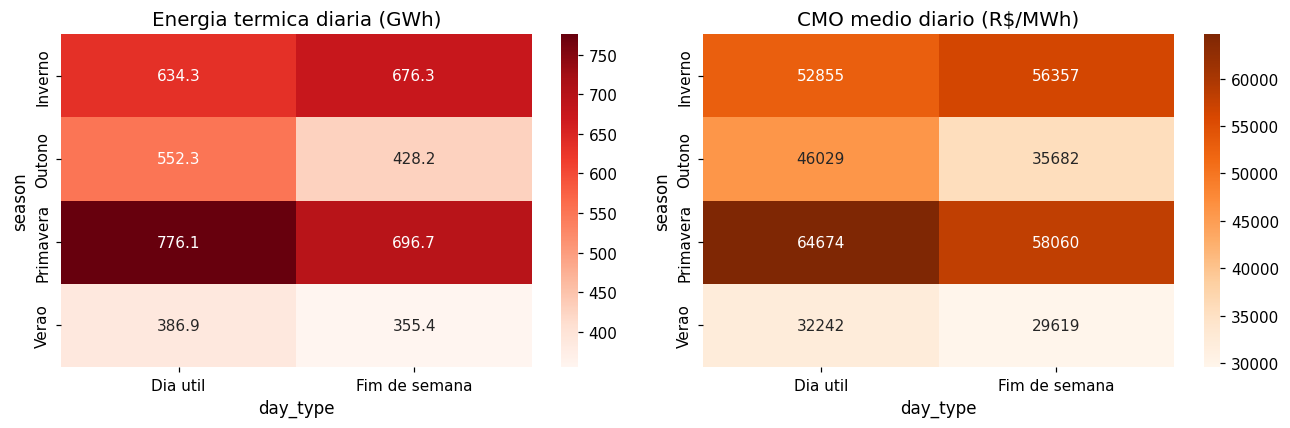

In [6]:
plot_df = df_base_daily.copy()
plot_df["season"] = plot_df["label"].str.split(" | ", regex=False).str[0]
plot_df["day_type"] = plot_df["label"].str.split(" | ", regex=False).str[1]

pivot_gt = plot_df.pivot(index="season", columns="day_type", values="gt_energy_GWh")
pivot_cmo = plot_df.pivot(index="season", columns="day_type", values="CMO_mean")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(pivot_gt, annot=True, fmt=".1f", cmap="Reds", ax=axes[0])
axes[0].set_title("Energia termica diaria (GWh)")

sns.heatmap(pivot_cmo, annot=True, fmt=".0f", cmap="Oranges", ax=axes[1])
axes[1].set_title("CMO medio diario (R$/MWh)")

fig.tight_layout(); plt.show()


## 4. Permutacoes de dias

Agora separamos **demanda** e **oferta**. A demanda vem de um dia representativo e a oferta hidrica/solar vem de outro. Isso cria um experimento simples e util:

- se o perfil de oferta for deslocado para uma condicao mais favoravel, a termica cai;
- se a oferta for deslocada para uma condicao menos favoravel, a termica sobe e o CMO acompanha.

As quatro permutacoes abaixo cobrem trocas sazonais e tambem trocas entre dia util e fim de semana.


In [7]:
perm_day_specs = [
    {"scenario": "Demanda Verao util | Oferta Inverno util", "demand_label": "Verao | Dia util", "supply_label": "Inverno | Dia util"},
    {"scenario": "Demanda Inverno util | Oferta Verao util", "demand_label": "Inverno | Dia util", "supply_label": "Verao | Dia util"},
    {"scenario": "Demanda Primavera util | Oferta Primavera FDS", "demand_label": "Primavera | Dia util", "supply_label": "Primavera | Fim de semana"},
    {"scenario": "Demanda Outono FDS | Oferta Outono util", "demand_label": "Outono | Fim de semana", "supply_label": "Outono | Dia util"},
]

perm_day_results = []
perm_dispatch = {}

for spec in perm_day_specs:
    demand_date = pd.Timestamp(rep_days.loc[rep_days["label"] == spec["demand_label"], "date"].iloc[0])
    supply_date = pd.Timestamp(rep_days.loc[rep_days["label"] == spec["supply_label"], "date"].iloc[0])

    demand_day = day_frame(demand_date)
    supply_day = day_frame(supply_date)
    solved = solve_daily_dispatch(demand_day, supply_day)
    disp = solved["dispatch"]
    perm_dispatch[spec["scenario"]] = disp

    perm_day_results.append({
        "scenario": spec["scenario"],
        "demand_date": demand_date.date(),
        "supply_date": supply_date.date(),
        "status": solved["status"],
        "gt_mean": disp["gt"].mean(),
        "gt_peak": disp["gt"].max(),
        "gt_energy_GWh": disp["gt"].sum() / 1e3,
        "CMO_mean": disp["CMO"].mean(),
        "CMO_peak": disp["CMO"].max(),
        "shed_MWh": disp["shed"].sum(),
        "curt_GWh": disp["curt"].sum() / 1e3,
    })

df_perm_daily = pd.DataFrame(perm_day_results)
display(df_perm_daily.round(3))


c:\Users\joaof\AppData\Local\Programs\Python\Python310\lib\site-packages\cvxpy\problems\problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


,scenario,demand_date,supply_date,status,gt_mean,gt_peak,gt_energy_GWh,CMO_mean,CMO_peak,shed_MWh,curt_GWh
0,Demanda Verao util | Oferta Inverno util,2025-02-06,2025-06-02,optimal,39948.425,39948.519,958.762,79896.849,79897.037,12.444,0.005
1,Demanda Inverno util | Oferta Verao util,2025-06-02,2025-02-06,optimal_inaccurate,2599.374,2599.385,62.385,5198.748,5198.769,0.000,0.004
2,Demanda Primavera util | Oferta Primavera FDS,2025-09-15,2025-09-27,optimal,39200.196,39200.225,940.805,78400.392,78400.450,0.569,0.001
3,Demanda Outono FDS | Oferta Outono util,2025-03-23,2025-05-08,optimal,16094.492,16094.512,386.268,32188.985,32189.024,0.000,0.002


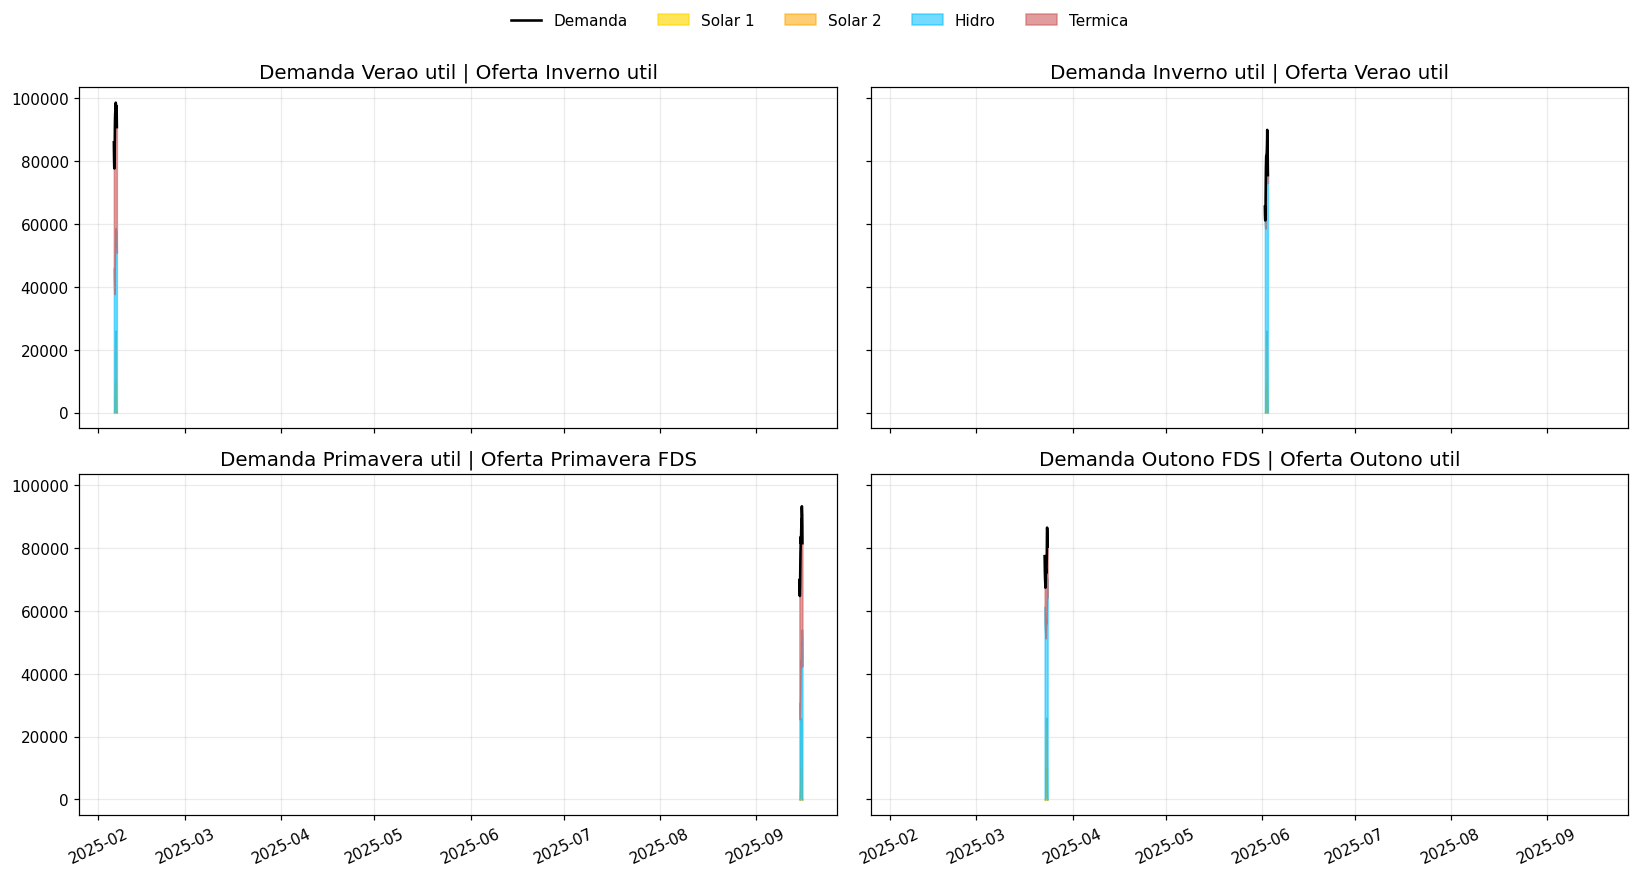

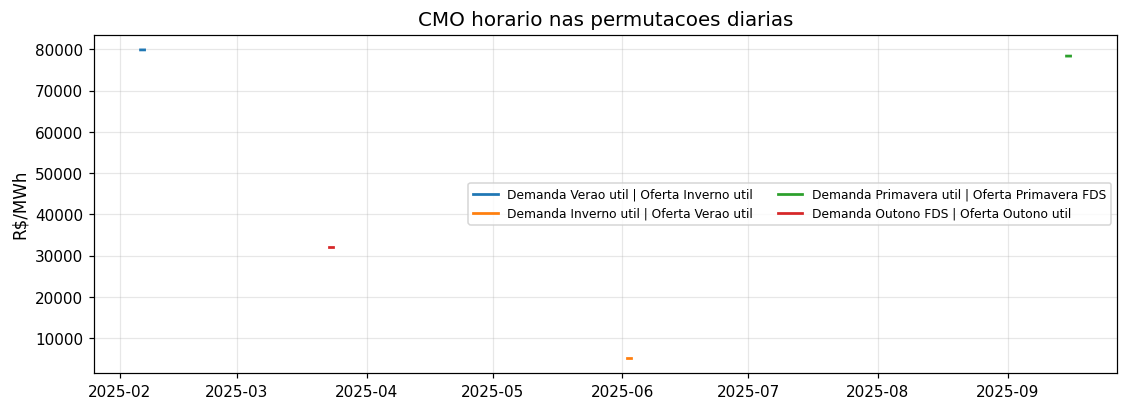

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharex=True, sharey=True)

for ax, (scenario, disp) in zip(axes.ravel(), perm_dispatch.items()):
    ax.plot(disp["din_instante"], disp["D"], color="black", lw=1.7, label="Demanda")
    ax.fill_between(disp["din_instante"], 0, disp["gs1"], color="gold", alpha=0.65, label="Solar 1")
    ax.fill_between(disp["din_instante"], disp["gs1"], disp["gs1"] + disp["gs2"], color="orange", alpha=0.55, label="Solar 2")
    ax.fill_between(disp["din_instante"], disp["gs1"] + disp["gs2"], disp["gs1"] + disp["gs2"] + disp["gh"], color="deepskyblue", alpha=0.55, label="Hidro")
    ax.fill_between(disp["din_instante"], disp["gs1"] + disp["gs2"] + disp["gh"], disp["gs1"] + disp["gs2"] + disp["gh"] + disp["gt"], color="indianred", alpha=0.60, label="Termica")
    ax.set_title(scenario)
    ax.grid(True, alpha=0.25)
    ax.tick_params(axis="x", rotation=25)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles[:5], labels[:5], loc="upper center", ncol=5, frameon=False)
fig.tight_layout(rect=(0, 0, 1, 0.95)); plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
for scenario, disp in perm_dispatch.items():
    ax.plot(disp["din_instante"], disp["CMO"], lw=1.8, label=scenario)
ax.set_title("CMO horario nas permutacoes diarias")
ax.set_ylabel("R$/MWh")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, ncol=2)
plt.show()


## 5. Transmissao: efeito simples no sistema

Para incorporar transmissao da maneira mais simples possivel, vamos supor que o **Painel Solar 2** e remoto e precisa atravessar uma linha ate o centro de carga.

Representacao adotada:

- `line_limit`: limite de exportacao da linha;
- `line_loss`: perda percentual na energia exportada;
- quanto menor a capacidade da linha ou maior a perda, menor a solar entregue e maior a necessidade de termica.

Isso nao substitui um modelo de fluxo em rede, mas ja mostra o mecanismo economico principal: restricao de transmissao desloca o equilibrio para mais termica e CMO maior.


In [9]:
stress_case = df_perm_daily.sort_values("gt_peak", ascending=False).iloc[0]
stress_name = stress_case["scenario"]
stress_spec = next(spec for spec in perm_day_specs if spec["scenario"] == stress_name)

demand_date = pd.Timestamp(rep_days.loc[rep_days["label"] == stress_spec["demand_label"], "date"].iloc[0])
supply_date = pd.Timestamp(rep_days.loc[rep_days["label"] == stress_spec["supply_label"], "date"].iloc[0])

demand_day = day_frame(demand_date)
supply_day = day_frame(supply_date)

tx_specs = [
    {"name": "Sem restricao", "line_limit": np.inf, "line_loss": 0.00},
    {"name": "Linha folgada", "line_limit": 5_000.0, "line_loss": 0.02},
    {"name": "Linha intermediaria", "line_limit": 3_500.0, "line_loss": 0.04},
    {"name": "Linha restrita", "line_limit": 2_000.0, "line_loss": 0.06},
]

tx_results = []
tx_dispatch = {}
for spec in tx_specs:
    solved = solve_daily_dispatch(
        demand_day,
        supply_day,
        line_limit=spec["line_limit"],
        line_loss=spec["line_loss"],
    )
    disp = solved["dispatch"]
    tx_dispatch[spec["name"]] = disp
    tx_results.append({
        "cenario": spec["name"],
        "gt_mean": disp["gt"].mean(),
        "gt_peak": disp["gt"].max(),
        "gt_energy_GWh": disp["gt"].sum() / 1e3,
        "CMO_mean": disp["CMO"].mean(),
        "CMO_peak": disp["CMO"].max(),
        "shed_MWh": disp["shed"].sum(),
        "curt_GWh": disp["curt"].sum() / 1e3,
        "solar2_spilled_GWh": solved["solar2_spilled_GWh"],
    })

df_tx = pd.DataFrame(tx_results)
display(df_tx.round(3))


,cenario,gt_mean,gt_peak,gt_energy_GWh,CMO_mean,CMO_peak,shed_MWh,curt_GWh,solar2_spilled_GWh
0,Sem restricao,39948.425,39948.519,958.762,79896.849,79897.037,12.444,0.005,0.000
1,Linha folgada,42842.439,42842.463,1028.219,85684.879,85684.925,0.001,0.002,68.391
2,Linha intermediaria,43445.871,43445.887,1042.701,86891.741,86891.773,0.022,0.002,82.391
3,Linha restrita,44073.110,44073.133,1057.755,88146.219,88146.265,0.047,0.000,97.595


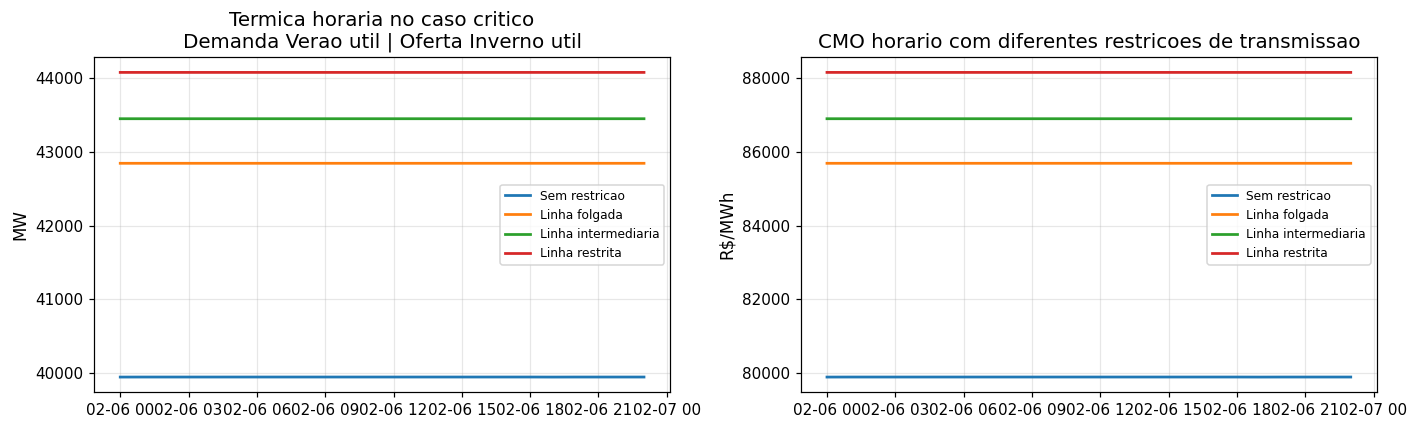

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
for name, disp in tx_dispatch.items():
    ax.plot(disp["din_instante"], disp["gt"], lw=1.8, label=name)
ax.set_title(f"Termica horaria no caso critico\n{stress_name}")
ax.set_ylabel("MW")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

ax = axes[1]
for name, disp in tx_dispatch.items():
    ax.plot(disp["din_instante"], disp["CMO"], lw=1.8, label=name)
ax.set_title("CMO horario com diferentes restricoes de transmissao")
ax.set_ylabel("R$/MWh")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

fig.tight_layout(); plt.show()


## 6. Leitura final do estudo

In [11]:
base_best = df_base_daily.loc[df_base_daily["gt_energy_GWh"].idxmin()]
base_worst = df_base_daily.loc[df_base_daily["gt_energy_GWh"].idxmax()]
perm_best = df_perm_daily.loc[df_perm_daily["gt_energy_GWh"].idxmin()]
perm_worst = df_perm_daily.loc[df_perm_daily["gt_energy_GWh"].idxmax()]
tx_worst = df_tx.loc[df_tx["gt_energy_GWh"].idxmax()]

print("Principais leituras:")
print(f"  1. Entre os dias representativos, o menor uso termico foi em {base_best['label']} ({base_best['gt_energy_GWh']:.2f} GWh).")
print(f"  2. O maior uso termico foi em {base_worst['label']} ({base_worst['gt_energy_GWh']:.2f} GWh).")
print(f"  3. A melhor permutacao foi '{perm_best['scenario']}' ({perm_best['gt_energy_GWh']:.2f} GWh termicos).")
print(f"  4. A pior permutacao foi '{perm_worst['scenario']}' ({perm_worst['gt_energy_GWh']:.2f} GWh termicos).")
print(f"  5. Na transmissao, o cenario mais restritivo levou a {tx_worst['gt_energy_GWh']:.2f} GWh termicos e CMO medio de {tx_worst['CMO_mean']:.1f} R$/MWh.")
print()
print("Conclusao curta:")
print("  Quando a oferta solar/hidrica e deslocada para perfis menos aderentes a demanda, a termica cresce e o CMO sobe quase linearmente com gt.")
print("  Restricoes de transmissao agravam esse efeito porque reduzem a energia renovavel efetivamente entregue ao centro de carga.")


Principais leituras:
  1. Entre os dias representativos, o menor uso termico foi em Verao | Fim de semana (355.43 GWh).
  2. O maior uso termico foi em Primavera | Dia util (776.09 GWh).
  3. A melhor permutacao foi 'Demanda Inverno util | Oferta Verao util' (62.38 GWh termicos).
  4. A pior permutacao foi 'Demanda Verao util | Oferta Inverno util' (958.76 GWh termicos).
  5. Na transmissao, o cenario mais restritivo levou a 1057.75 GWh termicos e CMO medio de 88146.2 R$/MWh.

Conclusao curta:
  Quando a oferta solar/hidrica e deslocada para perfis menos aderentes a demanda, a termica cresce e o CMO sobe quase linearmente com gt.
  Restricoes de transmissao agravam esse efeito porque reduzem a energia renovavel efetivamente entregue ao centro de carga.
